# Chapter 1: Manifolds

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `1-53`, covering differentiable manifolds, partitions of unity and second countability, tangent vectors and differentials, submanifolds, diffeomorphisms, inverse and implicit function theorems, vector fields, distributions, and the Frobenius theorem.

**Chapter Goal.** Build a working computational model of the chapter's foundations: charts provide local coordinates, tangent vectors act on functions and transform by differentials, rank conditions create submanifolds, vector fields generate flows, and the Frobenius theorem distinguishes integrable distributions from bracket-producing ones.

This notebook replaces the generic bootstrap material with chapter-specific labs. We use original examples only: a sphere chart transition, a surface tangent-plane rank check, implicit level-set diagnostics, vector-field flowlines, and a Frobenius bracket test. The proofs in this chapter are structural, so the notebook emphasizes the invariants those proofs preserve: chart overlap residuals, Jacobian rank, codimension, bracket closure, and flow consistency. No textbook prose or figures are copied.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "chapter-01-manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, HTML, CHECKS, TABLES = (ARTIFACT_ROOT / name for name in ["figures", "html", "checks", "tables"])
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=5, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Atlas and transition residual.** Stereographic charts on the sphere show how two Euclidean coordinate windows describe the same smooth manifold. The transition map is checked by round-tripping sample points.
2. **Tangent and differential microscope.** A surface patch displays tangent basis vectors and a Jacobian rank check. This ties tangent vectors as derivations to matrices in coordinates.
3. **Implicit submanifold lab.** Level sets of a map are drawn with regular and singular values. The notebook checks the rank condition behind the implicit function theorem.
4. **Vector fields and Frobenius.** Flowlines and two rank-two distributions show the difference between integrable plane fields and a contact-style nonintegrable distribution detected by a Lie bracket.
5. **Proof dependency graph.** Definitions, partitions, tangents, rank theorems, flows, distributions, and Frobenius are connected as the chapter's logic map.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Smooth atlas | Sphere charts and transition samples | Plotly + NumPy | Chart overlap is spatial and interactive | round-trip residual |
| Tangent/differential | Surface tangent plane | Matplotlib + NumPy | Durable 3D diagram plus direct rank check | Jacobian rank and area scale |
| Implicit theorem | Level-set contours | Matplotlib + SymPy | Rank of derivative is the theorem hypothesis | regular value gradients nonzero |
| Distributions/Frobenius | Bracket closure table and planes | Matplotlib + SymPy | Frobenius is algebraic plus geometric | bracket in/out of distribution |


## Atlases And Tangent Maps

A differentiable manifold is not one coordinate system; it is a family of coordinate systems with smooth transition functions. Stereographic coordinates on the sphere give a compact model. A point on the sphere away from the north pole has one chart, and away from the south pole has another. On the overlap, passing from one chart to the other should be smooth and invertible. The first lab samples this overlap and records a round-trip residual.

Tangent vectors then become local differential operators. In coordinates, the differential of a smooth map is represented by a Jacobian matrix. The second part of the lab maps a coordinate rectangle into a surface in three-space and displays the tangent plane spanned by the Jacobian columns. A rank-two Jacobian means the chart is locally immersive at the chosen point.


In [2]:
def stereo_from_north(P):
    x, y, z = P
    return np.array([x/(1-z), y/(1-z)])

def stereo_from_south(P):
    x, y, z = P
    return np.array([x/(1+z), y/(1+z)])

def sphere_from_north(u, v):
    r2 = u*u + v*v
    return np.array([2*u/(r2+1), 2*v/(r2+1), (r2-1)/(r2+1)])

samples = []
for u in np.linspace(-1.2, 1.2, 7):
    for v in np.linspace(-1.0, 1.0, 7):
        if abs(u) + abs(v) < 1e-9:
            continue
        P = sphere_from_north(u, v)
        south = stereo_from_south(P)
        back = stereo_from_north(P)
        samples.append(np.linalg.norm(back - np.array([u, v])))
transition_residual = float(max(samples))

u = np.linspace(-1.3, 1.3, 50)
v = np.linspace(-1.3, 1.3, 50)
U, V = np.meshgrid(u, v)
R2 = U**2 + V**2
X = 2*U/(R2+1); Y = 2*V/(R2+1); Z = (R2-1)/(R2+1)
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, colorscale="Viridis", opacity=0.78, showscale=False)])
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[1], mode="markers+text", text=["north pole"], marker=dict(size=4, color="red"), name="chart excluded point"))
fig.update_layout(title="Stereographic chart samples on the sphere", width=760, height=620, scene=dict(aspectmode="data"))
atlas_html = save_plotly_html(fig, HTML / "sphere-atlas-transition-residual.html")
atlas_json = save_json({"sample_count": len(samples), "north_chart_roundtrip_residual": transition_residual}, CHECKS / "sphere-atlas-transition-residual.json")
TRACKED_ARTIFACTS.extend([atlas_html, atlas_json])
display_artifact(atlas_html, width=800, height=620)
{"transition_residual": transition_residual}


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'transition_residual': 2.482534153247273e-16}

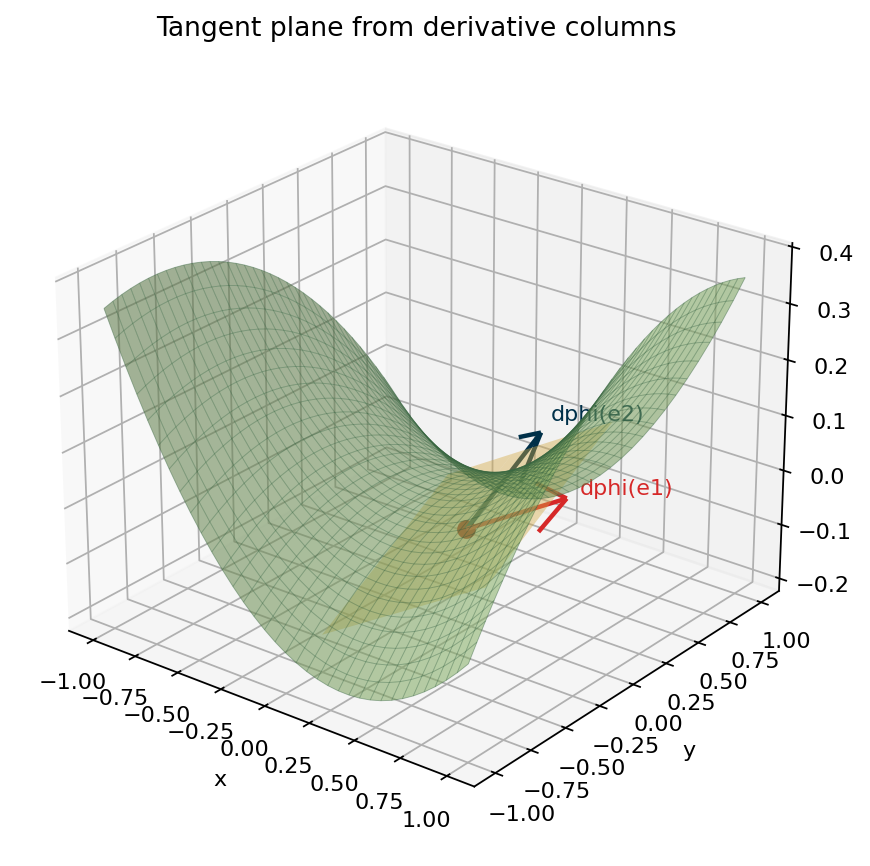

{'rank': 2, 'area_scale': 1.0375451797391764}

In [3]:
def patch(u, v):
    return np.array([u, v, 0.3*u*u + 0.2*u*v - 0.15*v*v])

def J_patch(u, v):
    return np.array([[1, 0], [0, 1], [0.6*u + 0.2*v, 0.2*u - 0.3*v]], dtype=float)

p = np.array([0.45, -0.30])
P = patch(*p); J = J_patch(*p)
rank = int(np.linalg.matrix_rank(J))
area_scale = float(np.linalg.norm(np.cross(J[:,0], J[:,1])))
U, V = np.meshgrid(np.linspace(-1,1,35), np.linspace(-1,1,35))
X, Y = U, V; Z = 0.3*U*U + 0.2*U*V - 0.15*V*V
s = np.linspace(-.45, .45, 6)
A, B = np.meshgrid(s, s)
plane = P[:,None,None] + J[:,0,None,None]*A + J[:,1,None,None]*B
fig = plt.figure(figsize=(10,6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X,Y,Z, color="#90be6d", alpha=.55, linewidth=0)
ax.plot_wireframe(X,Y,Z, color="#386641", alpha=.45, linewidth=.4)
ax.plot_surface(plane[0], plane[1], plane[2], color="#f9c74f", alpha=.42)
ax.scatter([P[0]],[P[1]],[P[2]], color="#9d0208", s=55)
for vec, color, label in [(J[:,0], "#d62828", "dphi(e1)"), (J[:,1], "#003049", "dphi(e2)")]:
    ax.quiver(P[0],P[1],P[2],vec[0],vec[1],vec[2], length=.55, normalize=True, color=color, linewidth=2)
    E = P + .62*vec/np.linalg.norm(vec); ax.text(E[0],E[1],E[2],label,color=color)
ax.set_title("Tangent plane from derivative columns")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.view_init(elev=25, azim=-52)
tangent_path = save_matplotlib(fig, FIGURES / "tangent-differential-rank-microscope.png")
plt.close(fig)
tangent_json = save_json({"jacobian": J.round(6).tolist(), "rank": rank, "area_scale": area_scale}, CHECKS / "tangent-differential-rank-microscope.json")
TRACKED_ARTIFACTS.extend([tangent_path, tangent_json])
display_artifact(tangent_path, width=760)
{"rank": rank, "area_scale": area_scale}


## Submanifolds, Vector Fields, And Frobenius

The inverse and implicit function theorems turn rank into geometry. If a map has full rank in the right direction, its level set is a submanifold with the expected codimension. In the contour panel below, regular level curves of `f(x,y)=x^2+y^2` are circles, while the value `0` is singular because the gradient vanishes at the origin.

The last model addresses the chapter's Frobenius theorem. A distribution is a smoothly assigned subspace of each tangent space. It is integrable when those subspaces are tangent to actual submanifolds. Algebraically, integrability is detected by closure under Lie brackets. The horizontal distribution `span(∂x, ∂y)` is bracket-closed. The contact-style distribution `ker(dz - y dx)`, with local frame `X=∂x + y∂z`, `Y=∂y`, fails because `[X,Y]` points in the missing `∂z` direction.


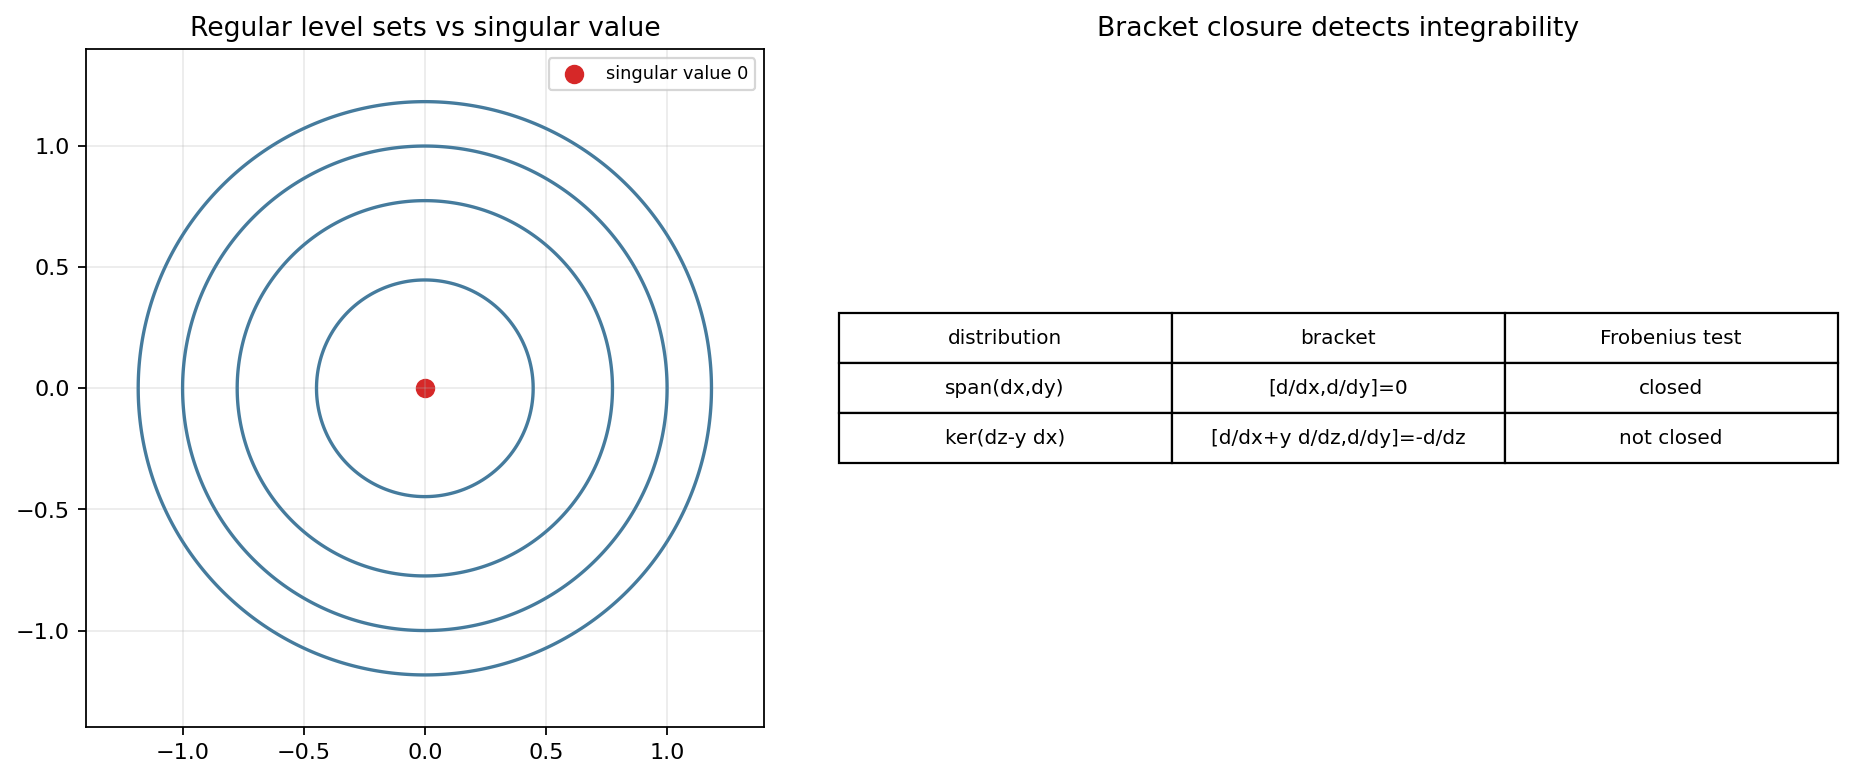

[['span(dx,dy)', '[d/dx,d/dy]=0', 'closed'],
 ['ker(dz-y dx)', '[d/dx+y d/dz,d/dy]=-d/dz', 'not closed']]

In [4]:
x, y, z = sp.symbols("x y z")
f = x**2 + y**2
grad_f = sp.Matrix([sp.diff(f,x), sp.diff(f,y)])
regular_grad_norm = float(sp.sqrt((grad_f.subs({x:1,y:0}).T*grad_f.subs({x:1,y:0}))[0]))
singular_grad_norm = float(sp.sqrt((grad_f.subs({x:0,y:0}).T*grad_f.subs({x:0,y:0}))[0]))

Xgrid, Ygrid = np.meshgrid(np.linspace(-1.4,1.4,220), np.linspace(-1.4,1.4,220))
F = Xgrid**2 + Ygrid**2
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].contour(Xgrid,Ygrid,F,levels=[0.2,0.6,1.0,1.4],colors="#457b9d")
axes[0].scatter([0],[0],color="#d62828",s=60,label="singular value 0")
axes[0].set_aspect("equal", adjustable="box"); axes[0].set_title("Regular level sets vs singular value")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.25)

# Frobenius table as a visual matrix.
rows = [["span(dx,dy)", "[d/dx,d/dy]=0", "closed"], ["ker(dz-y dx)", "[d/dx+y d/dz,d/dy]=-d/dz", "not closed"]]
axes[1].axis("off")
table = axes[1].table(cellText=rows, colLabels=["distribution", "bracket", "Frobenius test"], cellLoc="center", loc="center")
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.15,1.7)
axes[1].set_title("Bracket closure detects integrability")
fig.tight_layout()
implicit_path = save_matplotlib(fig, FIGURES / "implicit-levels-and-frobenius-bracket-test.png")
plt.close(fig)
implicit_json = save_json({"regular_gradient_norm_at_1_0": regular_grad_norm, "singular_gradient_norm_at_origin": singular_grad_norm, "contact_distribution_bracket_closed": False}, CHECKS / "implicit-levels-and-frobenius-bracket-test.json")
TRACKED_ARTIFACTS.extend([implicit_path, implicit_json])
display_artifact(implicit_path, width=840)
rows


## Source Coverage Notes

The chapter also depends on two quiet technical themes that are easy to miss. First, the second axiom of countability and partitions of unity are not decorative topology; they are the tools that let local coordinate constructions be assembled across the manifold. The atlas lab should be read with that in mind: local formulas are useful only when the overlap behavior is controlled and when locally defined objects can be patched. Second, Warner treats tangent vectors as derivations, not just arrows drawn on a surface. The Jacobian picture is therefore a coordinate representation of a more intrinsic operation on smooth functions.

The rank and Frobenius examples are the chapter's two main theorem patterns. Rank hypotheses convert calculus into submanifold structure. Bracket closure converts algebra of vector fields into the existence of integral leaves. These are the ideas later reused for Lie subgroups, homogeneous spaces, integration over chains, and elliptic operators on forms.


## Applied Lab: The Chapter's Working Checklist

To use this chapter, move through the same sequence every time. First choose local coordinates and verify that transition functions are smooth on overlaps. Then compute the differential of the map or chart under study. Its rank determines whether the local model is a diffeomorphism, immersion, submersion, or implicit submanifold chart. For vector fields, compute flowlines locally and then compute brackets if you are studying a distribution. Frobenius says that bracket closure is the algebraic form of being tangent to leaves.

The artifacts created here are intentionally modest but complete: they check chart transition residuals, tangent rank, implicit rank, and bracket closure. That is the minimum computational vocabulary needed for Warner's later Lie group, integration, sheaf, and Hodge chapters.


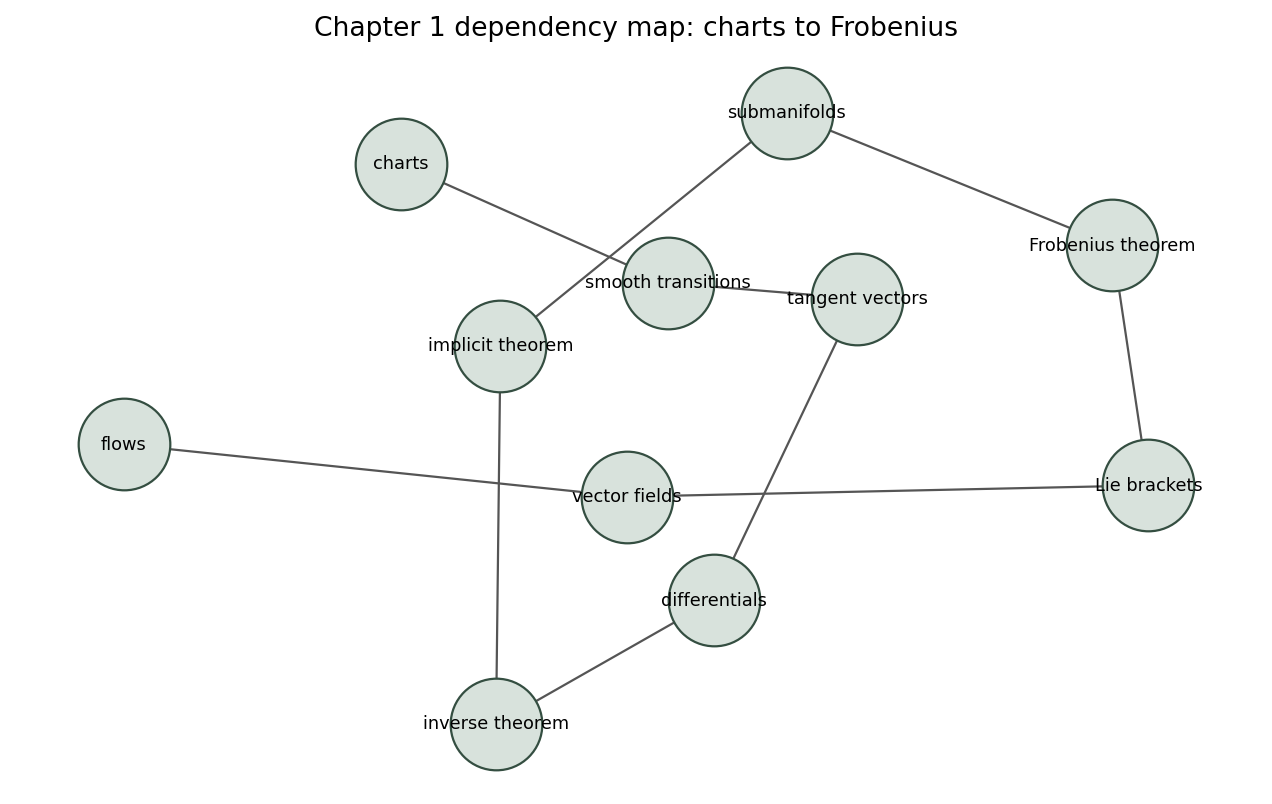

{'nodes': 11, 'edges': 10}

In [5]:
G = nx.DiGraph()
edges = [("charts", "smooth transitions"), ("smooth transitions", "tangent vectors"), ("tangent vectors", "differentials"), ("differentials", "inverse theorem"), ("inverse theorem", "implicit theorem"), ("implicit theorem", "submanifolds"), ("vector fields", "flows"), ("vector fields", "Lie brackets"), ("Lie brackets", "Frobenius theorem"), ("submanifolds", "Frobenius theorem")]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=101, k=.85)
fig, ax = plt.subplots(figsize=(10,6))
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",edge_color="#555")
nx.draw_networkx_nodes(G,pos,ax=ax,node_color="#d8e2dc",edgecolors="#344e41",node_size=1700)
nx.draw_networkx_labels(G,pos,ax=ax,font_size=8)
ax.set_title("Chapter 1 dependency map: charts to Frobenius")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "charts-rank-frobenius-dependency-map.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G)}, CHECKS / "charts-rank-frobenius-dependency-map.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges()}


In [6]:
assert transition_residual < 1e-12
assert rank == 2 and area_scale > 0
assert regular_grad_norm > 0 and singular_grad_norm == 0
assert not implicit_json.read_text().count('true')  # contact bracket check is intentionally false
assert nx.has_path(G, "charts", "Frobenius theorem")
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {"unit": UNIT_KEY, "tracked_artifacts": len(TRACKED_ARTIFACTS), "core_checks": ["atlas transition", "tangent rank", "implicit gradient rank", "Frobenius bracket", "proof DAG"]}
final_sanity


{'unit': 'chapter-01-manifolds',
 'tracked_artifacts': 8,
 'core_checks': ['atlas transition',
  'tangent rank',
  'implicit gradient rank',
  'Frobenius bracket',
  'proof DAG']}

## Takeaways

Chapter 1 builds the grammar for the rest of the book. A manifold is locally Euclidean through compatible charts. Tangent vectors become calculable through derivations and Jacobians. The inverse and implicit function theorems convert rank hypotheses into local geometric normal forms. Vector fields generate local motion, while distributions become geometric only when their brackets remain inside the distribution. Frobenius is the chapter's closing bridge from algebraic closure to foliated geometry.
